## Exploratory Data Analysis voor klachten train set
### Notebook EDA klachten classificatie voor correcte expertise

### Inhoud

1. [Introductie](#exploratory-data-analysis-voor-klachten-train-set)
2. [Data Analyse](#data-analyse)
   - [Visualisaties](#visualisaties)
   - [Productsspecifieke Analyse](#analyse-per-product)
   - [Wordclouds](#wordcloud-per-product)
3. [Data Preperation](#data-preperation)

In [187]:
# Imports Libraries
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import classification_report
from scipy.stats import uniform, randint
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

In [188]:
# Natural language ToolKit downloads
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\casde\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\casde\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\casde\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [189]:
#read training dataset
df = pd.read_csv("klachtengoed.csv")

### Data Analyse

In [190]:
# Klein Overzicht van dataset
df.head().T

,0,1,2,3,4
ID,2234392,2447005,2124501,1851449,2419713
Datum_ontvangst,2024-12-03,2025-04-21,2024-09-21,2024-03-27,2025-04-04
Product,Bankrekening,Bankrekening,Bankrekening,Bankrekening,Bankrekening
Omschrijving,ON XX/XX/2016 I had a deposit of XXXX into my ...,Chase Bank accepted a {$3500.00} check for dep...,I tried to open an account with Bank of Americ...,On XXXX my account was gotten into on USAA by ...,I have been deprived of my income as Bank of A...
Antwoord_bedrijf,Closed with monetary relief,Closed with explanation,Closed with explanation,Closed with explanation,Closed with explanation


In [191]:
# Informatie over dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14887 entries, 0 to 14886
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   ID                14887 non-null  int64 
 1   Datum_ontvangst   14887 non-null  object
 2   Product           14887 non-null  object
 3   Omschrijving      14887 non-null  object
 4   Antwoord_bedrijf  14887 non-null  object
dtypes: int64(1), object(4)
memory usage: 581.6+ KB


In [192]:
# Kleine numerieke weergave van dataset
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,14887.0,1.902949e+06,341759.949815,1290157.0,1602145.5,1923756.0,2205762.5,2543247.0


In [193]:
# Kolom/Product namen
df['Product'].unique()

array(['Bankrekening', 'Consumentenkrediet', 'Creditcard', 'Hypotheek',
       'Incasso', 'Kredietregistratie'], dtype=object)

In [194]:
# Bedrijfsantwoorden
df['Antwoord_bedrijf'].unique()

array(['Closed with monetary relief', 'Closed with explanation',
       'Closed with non-monetary relief', 'Closed', 'Untimely response'],
      dtype=object)

In [195]:
# Datum reeks dataset
df['Datum_ontvangst'].agg(['min', 'max'])

min    2023-03-19
max    2025-04-30
Name: Datum_ontvangst, dtype: object

In [196]:
# informatie over dataset
df.shape
print("De dataset bevat {} rijen en {} kolommen.".format(df.shape[0], df.shape[1]))

De dataset bevat 14887 rijen en 5 kolommen.


In [197]:
# Numerieke tabel
stats_num = df.describe(include='int64').T.reset_index().T
stats_num

,0
index,ID
count,14887.0
mean,1902949.056291
std,341759.949815
min,1290157.0
25%,1602145.5
50%,1923756.0
75%,2205762.5
max,2543247.0


In [198]:
# Categorisch data overzicht
stats_cat = df.describe(include='object').T.reset_index()
stats_cat

,index,count,unique,top,freq
0,Datum_ontvangst,14887,771,2024-09-21,43
1,Product,14887,6,Incasso,4094
2,Omschrijving,14887,14816,I am filing this complaint because Experian ha...,10
3,Antwoord_bedrijf,14887,5,Closed with explanation,11610


In [199]:
# Verdeling verschillende expertises binnen de dataset
df['Product'].value_counts()

Product
Incasso               4094
Hypotheek             3314
Kredietregistratie    3159
Creditcard            1884
Bankrekening          1489
Consumentenkrediet     947
Name: count, dtype: int64

In [200]:
train_df, test_df = train_test_split(df, test_size=0.20, random_state=42)

In [201]:
train_df.to_csv("klachttrain.csv", index=False)
test_df.to_csv("klachttest.csv", index=False)

In [202]:
# Inlezen train en test data
train = pd.read_csv("klachttrain.csv")
test = pd.read_csv("klachttest.csv")

In [203]:
# Weergave lege waarden
train.isnull().sum()

ID                  0
Datum_ontvangst     0
Product             0
Omschrijving        0
Antwoord_bedrijf    0
dtype: int64

In [204]:
# Weergave duplicaten
train.duplicated().sum()

np.int64(0)

In [205]:
# Korte Tabele lengte van klachten en antwoorden
train.drop(columns=['ID']).describe().T

,count,unique,top,freq
Datum_ontvangst,11909,770,2024-10-17,38
Product,11909,6,Incasso,3237
Omschrijving,11909,11859,I am filing this complaint because Experian ha...,8
Antwoord_bedrijf,11909,5,Closed with explanation,9281


#### Visualisaties

In [206]:
# bepaal numerieke variabelen
num_vars = train.drop(columns=['ID']).select_dtypes(include=np.number).columns.tolist()

# plot de verdeling van elke numerieke variabele in histogram en boxplot
for var in num_vars:
    plt.figure(figsize = (15, 4))
    plt.subplot(1, 2, 1)
    plt.hist(train[var])
    plt.subplot(1, 2, 2)
    sns.boxplot(x=train[var])
    plt.show()


In [207]:
# Numerieke weergave kort
train.select_dtypes(include="number").corr()

,ID
ID,1.0


<Axes: >

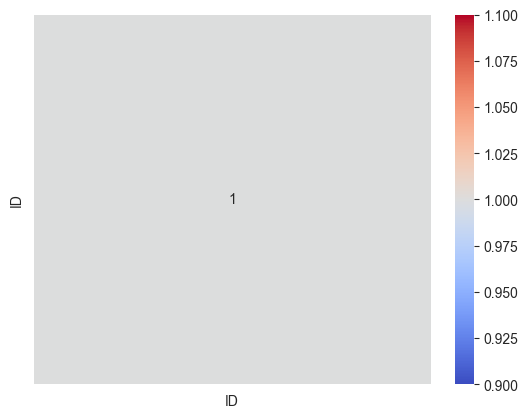

In [208]:
# Heatmap Trainingsdata
sns.heatmap(train.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm")

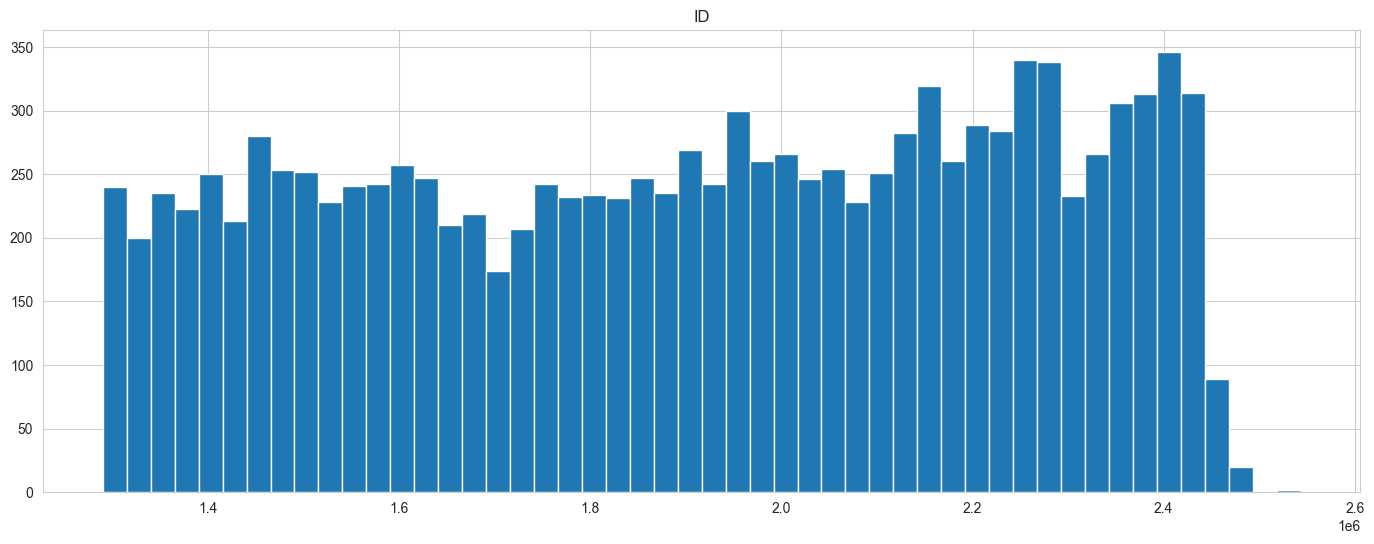

In [209]:
# Histogrammen trainingsdata
train.hist(bins=50, figsize=(17, 6))
plt.show()

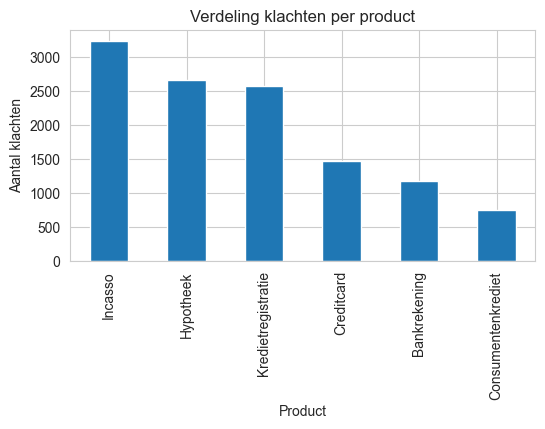

In [210]:
# Bar chart voor Product
plt.figure(figsize=(6,3))
train['Product'].value_counts().plot(kind="bar")
plt.title("Verdeling klachten per product")
plt.xlabel("Product")
plt.ylabel("Aantal klachten")
plt.show()

Incasso ontvangt de meeste klachten

### Analyse per product

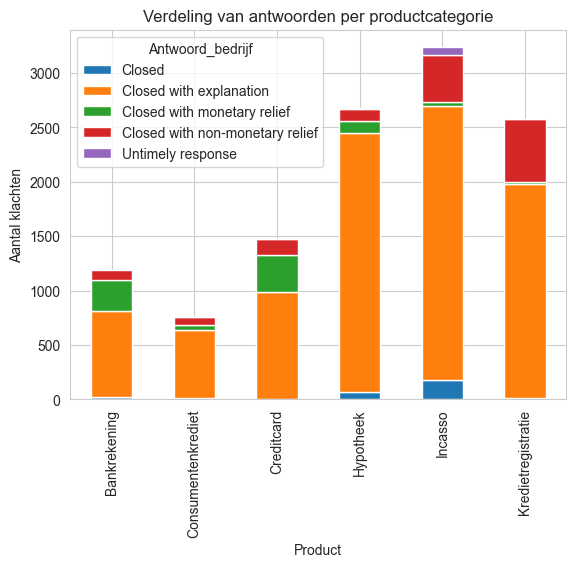

In [211]:
# Staafdiagrammen trainingsdata
pd.crosstab(train["Product"], train["Antwoord_bedrijf"]).plot(kind="bar", stacked=True)
plt.title("Verdeling van antwoorden per productcategorie")
plt.ylabel("Aantal klachten")
plt.show()

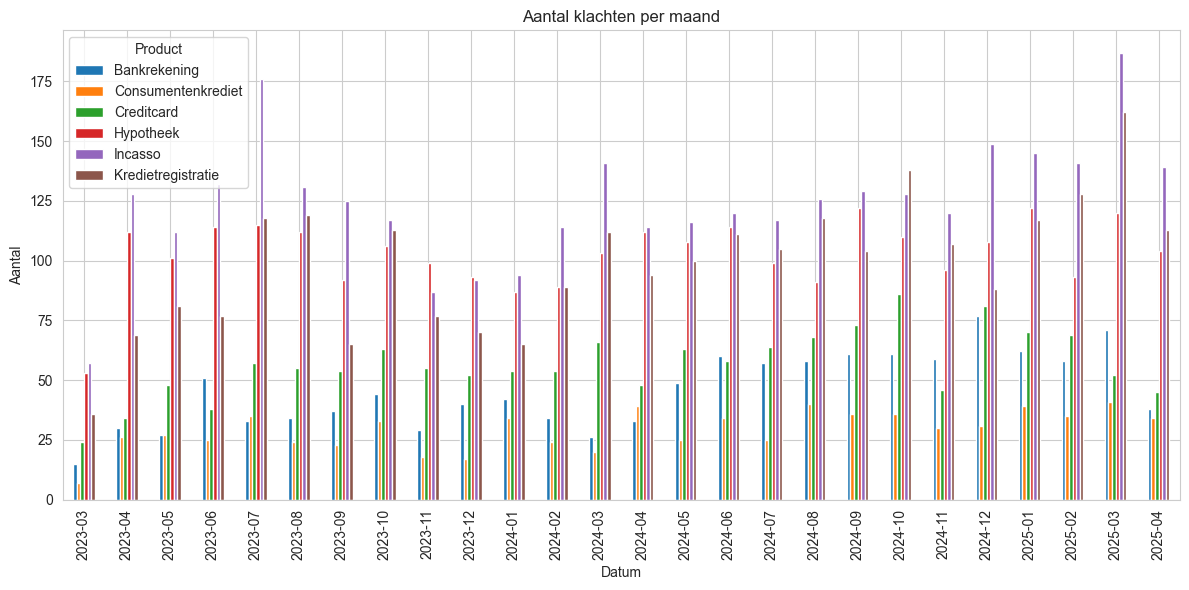

In [ ]:
# Datum naar datetime
train["Datum_ontvangst"] = pd.to_datetime(train["Datum_ontvangst"])

# Maandkolom
train["Datum"] = train["Datum_ontvangst"].dt.to_period("M")

# Aantal klachten per maand
counts = train.groupby(["Datum", "Product"]).size().unstack(fill_value=0)

# plt
counts.plot(kind="bar", figsize=(12,6))
plt.ylabel("Aantal")
plt.title("Aantal klachten per maand")
plt.tight_layout()
plt.show()

#### Wordcloud per product

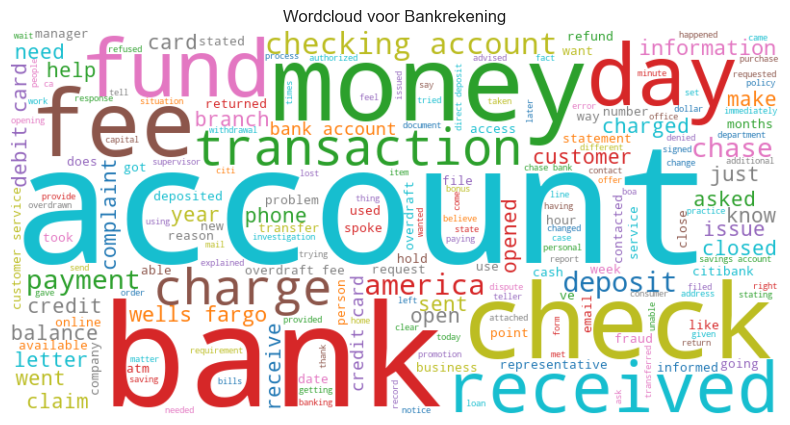

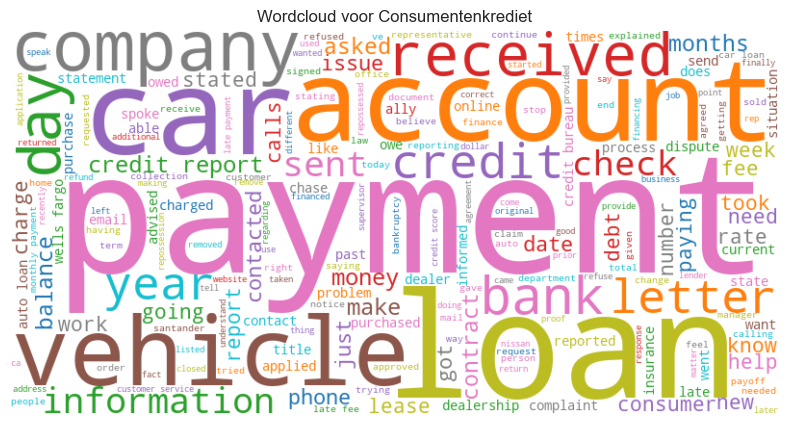

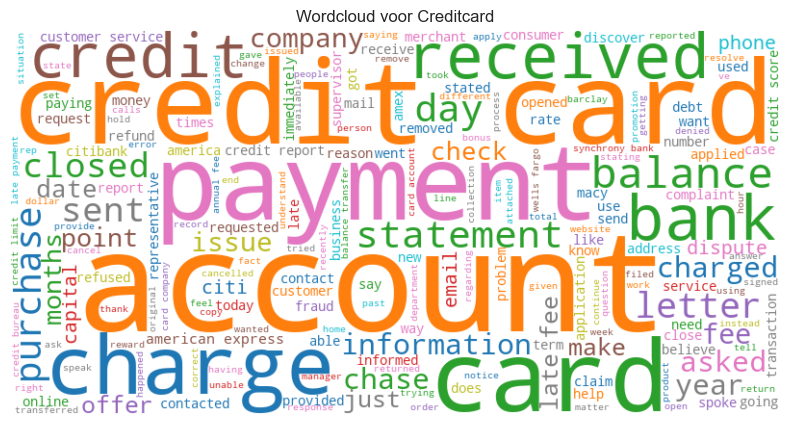

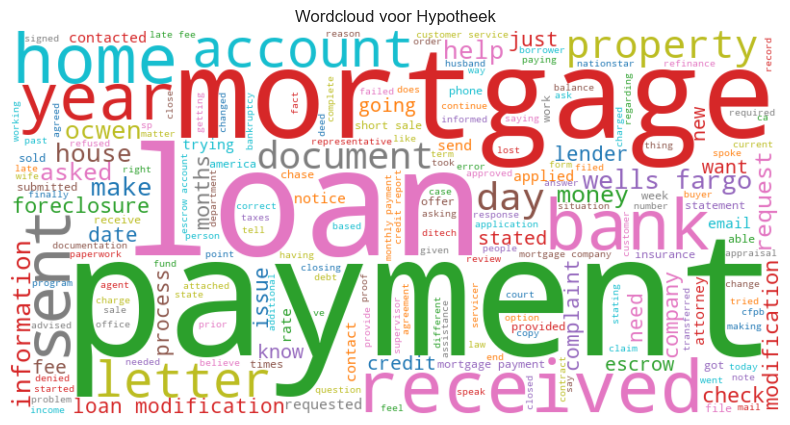

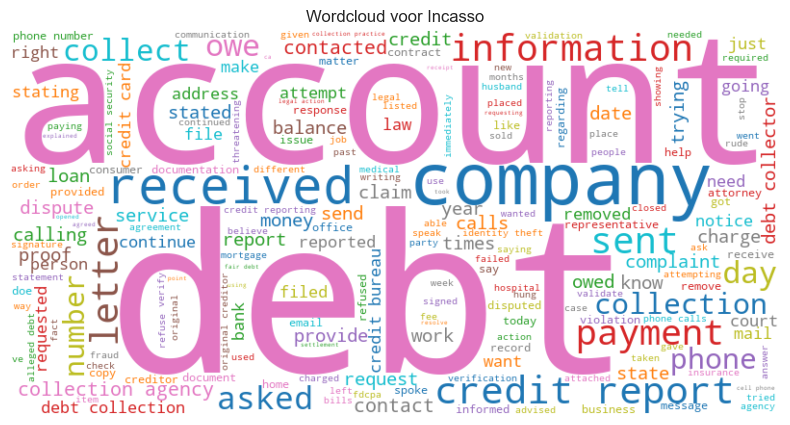

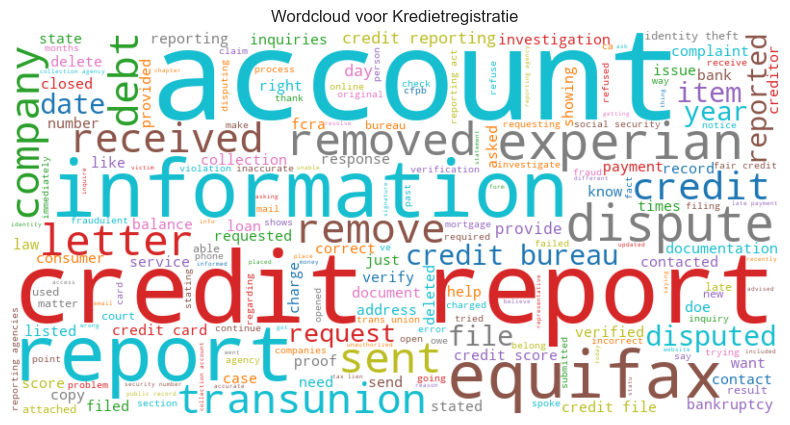

In [213]:
# Wordclouds per product

#stopwoorden = set(stopwords.words("english"))
stopwoorden = list(set(ENGLISH_STOP_WORDS).union({
    'xxxx', 'xx', 'xxx', 'did', 'please', 'told', 'paid', 'called', 'time', 'said', 'month', 'pay',
    'a','b','c','d','e','f','g','h','i','j','k','l','m','n', 'o','p','q','r','s','t','u','v','w','x','y','z'
}))

train["clean"] = train["Omschrijving"].fillna("").str.lower().str.replace(r'[^a-z\s]', ' ', regex=True)

# Vectorizer
vectorizer = TfidfVectorizer(stop_words=stopwoorden, max_features=100000)
tfidf = vectorizer.fit_transform(train["clean"])
woorden = vectorizer.get_feature_names_out()

train["Top_keywords"] = [
    [woorden[i] for i in tfidf[row].toarray()[0].argsort()[-5:][::-1]]
    for row in range(tfidf.shape[0])
]

for product, groep in train.groupby("Product"):
    tekst = " ".join(groep["clean"])
    wc = WordCloud(width=800, height=400, background_color="white",
                   stopwords=set(stopwoorden), colormap="tab10").generate(tekst)
    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Wordcloud voor {product}")
    plt.show()

<Axes: xlabel='Product'>

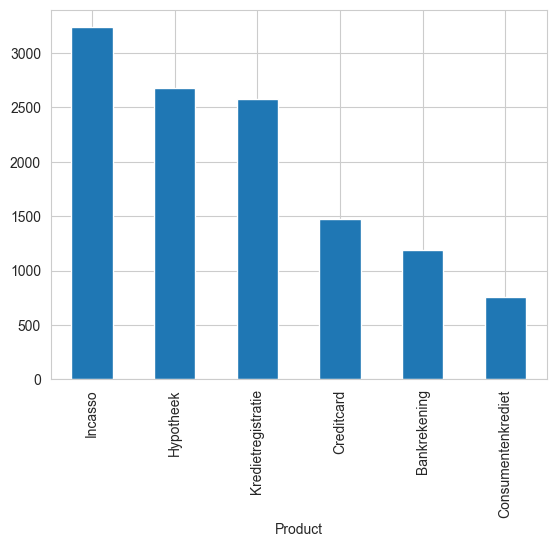

In [214]:
train["Product"].value_counts().plot(kind="bar")

## Data Preperation

In [215]:
# Stopwords en Lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [216]:
# preprocessing, tokenizer
def preprocess_text(text):
    if pd.isna(text):
        return""
    
    text = text.lower() # maak lowercase
    text = re.sub(r'[^a-z\s]', ' ', text) # verwijdert speciale tekens 
    tokens = word_tokenize(text)

    tokens = [t for t in tokens if t not in stop_words] # verwijdert stopwords
    tokens = [lemmatizer.lemmatize(t) for t in tokens] # lemmatizen

    return ' '.join(tokens)

df['Omschrijving_Cleaned'] = df['Omschrijving'].apply(preprocess_text)

In [217]:
# Vergelijking omschrijving en opgeschoonde omschrijving
df[['Omschrijving', 'Omschrijving_Cleaned']].head()

,Omschrijving,Omschrijving_Cleaned
0,ON XX/XX/2016 I had a deposit of XXXX into my ...,xx xx deposit xxxx account day xxxx different ...
1,Chase Bank accepted a {$3500.00} check for dep...,chase bank accepted check deposit made payable...
2,I tried to open an account with Bank of Americ...,tried open account bank america without giving...
3,On XXXX my account was gotten into on USAA by ...,xxxx account gotten usaa phone number xxxx xxx...
4,I have been deprived of my income as Bank of A...,deprived income bank america continues disappe...


#### Vordering in modelling.ipynb